# Seed Sweep Summary

This notebook reads `results/seed_sweeps/` outputs and prepares tables and error-bar plots for the stability, real near-tie slice, and bootstrap experiments. It does not refit models.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

ROOT = Path.cwd()
if ROOT.name != 'experiments':
    ROOT = ROOT / 'experiments'
SEED_SWEEP_DIR = ROOT / 'results' / 'seed_sweeps'
FIG_DIR = SEED_SWEEP_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

METHOD_LABELS = {
    'proposed': 'Proposed',
    'proposed_full_rank': 'Proposed full rank',
    'zhou_github': 'Zhou github',
    'standard_btl': 'Standard BTL',
}
METHOD_ORDER = ['proposed', 'proposed_full_rank', 'zhou_github', 'standard_btl']
METHOD_COLORS = {
    'proposed': '#2f6fbb',
    'proposed_full_rank': '#5aa2d6',
    'zhou_github': '#d08a24',
    'standard_btl': '#6b7280',
}

def load_summary(experiment):
    path = SEED_SWEEP_DIR / f'{experiment}_seed_sweep_summary.json'
    if not path.exists():
        print(f'Missing {path}')
        return None
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    data['_path'] = str(path)
    return data

summaries = {
    name: load_summary(name)
    for name in ['stability', 'near_tie_slice', 'bootstrap']
}
available = {name: data for name, data in summaries.items() if data is not None}
available.keys()

dict_keys(['stability', 'near_tie_slice', 'bootstrap'])

## Run Metadata

In [2]:
metadata_rows = []
for name, data in available.items():
    metadata_rows.append({
        'experiment': name,
        'n_seeds': len(data.get('seeds', [])),
        'seeds': ','.join(str(seed) for seed in data.get('seeds', [])),
        'dataset_filter': data.get('dataset'),
        'path': data.get('_path'),
    })
metadata_df = pd.DataFrame(metadata_rows)
metadata_df

,experiment,n_seeds,seeds,dataset_filter,path
0,stability,20,"11,17,23,29,31,37,41,42,43,47,53,59,61,67,71,7...",None,/home/jinhongd/projects/JA-Ranking/experiments...
1,near_tie_slice,20,"11,17,23,29,31,37,41,42,43,47,53,59,61,67,71,7...",None,/home/jinhongd/projects/JA-Ranking/experiments...
2,bootstrap,5,"11,17,23,29,31",None,/home/jinhongd/projects/JA-Ranking/experiments...


## Helpers

In [3]:
def stat_value(stat, key):
    if isinstance(stat, dict):
        return stat.get(key)
    return None

def ordered_methods(methods):
    methods = list(methods)
    return [m for m in METHOD_ORDER if m in methods] + sorted(m for m in methods if m not in METHOD_ORDER)

def compact_stat(row, mean_col='mean', err_col='stderr', digits=3):
    mean = row.get(mean_col)
    err = row.get(err_col)
    if pd.isna(mean):
        return ''
    if pd.isna(err):
        return f'{mean:.{digits}f}'
    return f'{mean:.{digits}f} +/- {err:.{digits}f}'

def plot_grouped_errorbars(df, metric, title, ylabel, save_name=None, methods=None, datasets=None, ylim=None):
    plot_df = df[df['metric'].eq(metric)].copy()
    if methods is not None:
        plot_df = plot_df[plot_df['method'].isin(methods)]
    if datasets is not None:
        plot_df = plot_df[plot_df['dataset'].isin(datasets)]
    if plot_df.empty:
        print(f'No rows for metric={metric}')
        return None

    dataset_order = list(dict.fromkeys(plot_df['dataset']))
    method_order = ordered_methods(plot_df['method'].unique())
    x = np.arange(len(dataset_order))
    width = 0.8 / max(1, len(method_order))

    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(dataset_order)), 4.5))
    for idx, method in enumerate(method_order):
        sub = plot_df[plot_df['method'].eq(method)].set_index('dataset')
        means = [sub.loc[d, 'mean'] if d in sub.index else np.nan for d in dataset_order]
        errs = [sub.loc[d, 'stderr'] if d in sub.index else np.nan for d in dataset_order]
        offsets = x + (idx - (len(method_order) - 1) / 2) * width
        ax.bar(
            offsets,
            means,
            width=width,
            yerr=errs,
            capsize=3,
            label=METHOD_LABELS.get(method, method),
            color=METHOD_COLORS.get(method),
            alpha=0.9,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_order, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(frameon=True)
    fig.tight_layout()
    if save_name:
        out_path = FIG_DIR / save_name
        fig.savefig(out_path, dpi=180, bbox_inches='tight')
        print(f'Saved {out_path}')
    return fig, ax

## Stability: Held-Out Accuracy

In [4]:
def flatten_stability(summary):
    rows = []
    if summary is None:
        return pd.DataFrame(rows)
    for dataset, dataset_summary in summary.get('summary', {}).items():
        for method, method_summary in dataset_summary.get('methods', {}).items():
            stat = method_summary.get('test_accuracy', {})
            rows.append({
                'dataset': dataset,
                'method': method,
                'metric': 'test_accuracy',
                'n': stat_value(stat, 'n'),
                'mean': stat_value(stat, 'mean'),
                'std': stat_value(stat, 'std'),
                'stderr': stat_value(stat, 'stderr'),
                'min': stat_value(stat, 'min'),
                'max': stat_value(stat, 'max'),
                'selected_ranks': dataset_summary.get('selected_ranks'),
            })
    return pd.DataFrame(rows)

stability_df = flatten_stability(summaries.get('stability'))
stability_df['display'] = stability_df.apply(compact_stat, axis=1)
stability_table = stability_df.pivot(index='dataset', columns='method', values='display')
stability_table = stability_table[[m for m in ordered_methods(stability_table.columns) if m in stability_table.columns]]
stability_table

method,proposed,zhou_github,standard_btl
dataset,,,
chatbot_arena,0.651 +/- 0.002,0.584 +/- 0.002,0.584 +/- 0.002
in_house,0.616 +/- 0.001,0.608 +/- 0.001,0.608 +/- 0.001
mtbench,0.760 +/- 0.002,0.696 +/- 0.001,0.696 +/- 0.001
ultrafeedback,0.699 +/- 0.002,0.615 +/- 0.002,0.614 +/- 0.002


Saved /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/figures/stability_accuracy_errorbars.png


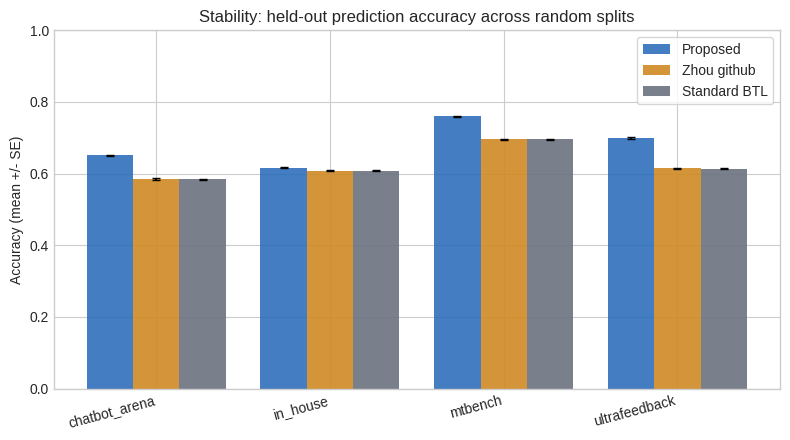

In [5]:
plot_grouped_errorbars(
    stability_df,
    metric='test_accuracy',
    title='Stability: held-out prediction accuracy across random splits',
    ylabel='Accuracy (mean +/- SE)',
    save_name='stability_accuracy_errorbars.png',
    methods=['proposed', 'zhou_github', 'standard_btl'],
    ylim=(0, 1),
);

## Near-Tie Slice

In [6]:
def flatten_near_tie(summary):
    rows = []
    if summary is None:
        return pd.DataFrame(rows)
    metric_names = [
        'test_accuracy',
        'near_tie_log_loss',
        'other_log_loss',
        'near_tie_accuracy_no_ties',
        'other_accuracy_no_ties',
    ]
    for dataset, dataset_summary in summary.get('summary', {}).items():
        for method, method_summary in dataset_summary.get('methods', {}).items():
            for metric in metric_names:
                stat = method_summary.get(metric, {})
                rows.append({
                    'dataset': dataset,
                    'method': method,
                    'metric': metric,
                    'n': stat_value(stat, 'n'),
                    'mean': stat_value(stat, 'mean'),
                    'std': stat_value(stat, 'std'),
                    'stderr': stat_value(stat, 'stderr'),
                    'min': stat_value(stat, 'min'),
                    'max': stat_value(stat, 'max'),
                    'selected_ranks': dataset_summary.get('selected_ranks'),
                })
    return pd.DataFrame(rows)

near_tie_df = flatten_near_tie(summaries.get('near_tie_slice'))
near_tie_df['display'] = near_tie_df.apply(compact_stat, axis=1)
near_tie_df.head()

,dataset,method,metric,n,mean,std,stderr,min,max,selected_ranks,display
0,chatbot_arena,proposed,test_accuracy,20,0.650981,0.008098,0.001811,0.630096,0.662808,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.651 +/- 0.002
1,chatbot_arena,proposed,near_tie_log_loss,20,0.590104,0.027388,0.006124,0.547929,0.650045,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.590 +/- 0.006
2,chatbot_arena,proposed,other_log_loss,20,0.529864,0.008070,0.001805,0.517745,0.548230,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.530 +/- 0.002
3,chatbot_arena,proposed,near_tie_accuracy_no_ties,20,0.687006,0.020533,0.004591,0.646154,0.724444,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.687 +/- 0.005
4,chatbot_arena,proposed,other_accuracy_no_ties,20,0.752760,0.006432,0.001438,0.742403,0.764344,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.753 +/- 0.001


In [7]:
near_tie_accuracy_table = (
    near_tie_df[near_tie_df['metric'].isin(['near_tie_accuracy_no_ties', 'other_accuracy_no_ties'])]
    .assign(column=lambda d: d['method'].map(METHOD_LABELS).fillna(d['method']) + ' / ' + d['metric'])
    .pivot(index='dataset', columns='column', values='display')
)
near_tie_accuracy_table

column,Proposed / near_tie_accuracy_no_ties,Proposed / other_accuracy_no_ties,Standard BTL / near_tie_accuracy_no_ties,Standard BTL / other_accuracy_no_ties,Zhou github / near_tie_accuracy_no_ties,Zhou github / other_accuracy_no_ties
dataset,,,,,,
chatbot_arena,0.687 +/- 0.005,0.753 +/- 0.001,0.542 +/- 0.004,0.688 +/- 0.002,0.546 +/- 0.005,0.688 +/- 0.002
in_house,0.570 +/- 0.012,0.650 +/- 0.002,0.578 +/- 0.010,0.641 +/- 0.001,0.581 +/- 0.011,0.641 +/- 0.001
mtbench,0.825 +/- 0.002,,0.755 +/- 0.002,,0.756 +/- 0.002,
ultrafeedback,0.694 +/- 0.006,0.770 +/- 0.003,0.576 +/- 0.006,0.683 +/- 0.002,0.575 +/- 0.005,0.684 +/- 0.002


Saved /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/figures/near_tie_accuracy_errorbars.png
Saved /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/figures/near_tie_log_loss_errorbars.png


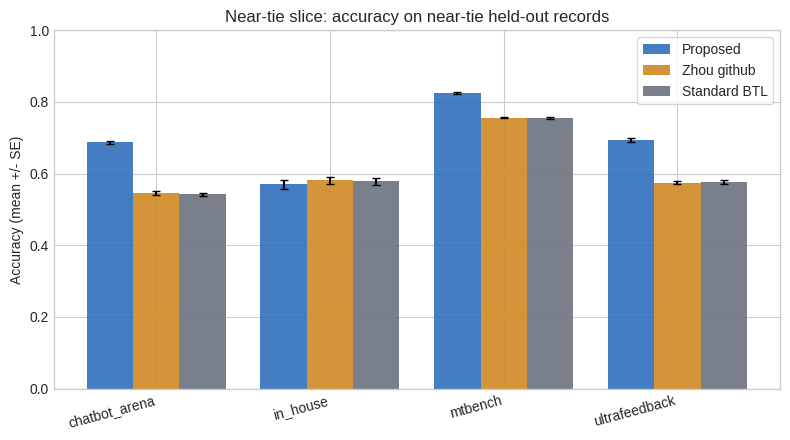

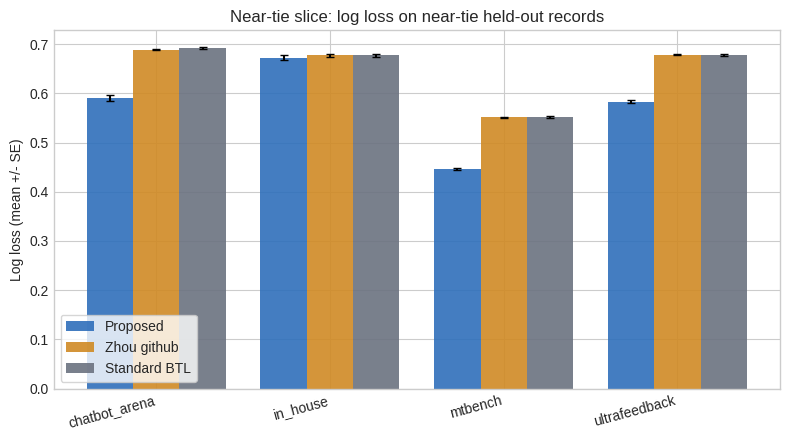

In [8]:
plot_grouped_errorbars(
    near_tie_df,
    metric='near_tie_accuracy_no_ties',
    title='Near-tie slice: accuracy on near-tie held-out records',
    ylabel='Accuracy (mean +/- SE)',
    save_name='near_tie_accuracy_errorbars.png',
    methods=['proposed', 'zhou_github', 'standard_btl'],
    ylim=(0, 1),
);

plot_grouped_errorbars(
    near_tie_df,
    metric='near_tie_log_loss',
    title='Near-tie slice: log loss on near-tie held-out records',
    ylabel='Log loss (mean +/- SE)',
    save_name='near_tie_log_loss_errorbars.png',
    methods=['proposed', 'zhou_github', 'standard_btl'],
);

## Bootstrap: Top-k Stability

In [9]:
def flatten_bootstrap(summary):
    rows = []
    if summary is None:
        return pd.DataFrame(rows)
    for dataset, dataset_summary in summary.get('summary', {}).items():
        for method, method_summary in dataset_summary.get('methods', {}).items():
            for top_k, metric_summary in method_summary.get('top_k', {}).items():
                for metric, stat in metric_summary.items():
                    rows.append({
                        'dataset': dataset,
                        'method': method,
                        'top_k': top_k,
                        'metric': metric,
                        'n': stat_value(stat, 'n'),
                        'mean': stat_value(stat, 'mean'),
                        'std': stat_value(stat, 'std'),
                        'stderr': stat_value(stat, 'stderr'),
                        'min': stat_value(stat, 'min'),
                        'max': stat_value(stat, 'max'),
                        'bootstrap_samples': dataset_summary.get('bootstrap_samples'),
                        'selected_ranks': dataset_summary.get('selected_ranks'),
                    })
    return pd.DataFrame(rows)

bootstrap_df = flatten_bootstrap(summaries.get('bootstrap'))
bootstrap_df['display'] = bootstrap_df.apply(compact_stat, axis=1)
bootstrap_df.head()

,dataset,method,top_k,metric,n,mean,std,stderr,min,max,bootstrap_samples,selected_ranks,display
0,chatbot_arena,proposed,top_3,exact_match_rate_vs_baseline_top_k,5,0.6960,0.002000,0.000894,0.694000,0.698000,500,"[1, 1, 1, 1, 1]",0.696 +/- 0.001
1,chatbot_arena,proposed,top_3,mean_jaccard_vs_baseline,5,0.9952,0.000447,0.000200,0.995000,0.996000,500,"[1, 1, 1, 1, 1]",0.995 +/- 0.000
2,chatbot_arena,proposed,top_5,exact_match_rate_vs_baseline_top_k,5,0.5076,0.001673,0.000748,0.506000,0.510000,500,"[1, 1, 1, 1, 1]",0.508 +/- 0.001
3,chatbot_arena,proposed,top_5,mean_jaccard_vs_baseline,5,0.9280,0.000471,0.000211,0.927333,0.928667,500,"[1, 1, 1, 1, 1]",0.928 +/- 0.000
4,chatbot_arena,proposed_full_rank,top_3,exact_match_rate_vs_baseline_top_k,5,0.7676,0.000894,0.000400,0.766000,0.768000,500,"[1, 1, 1, 1, 1]",0.768 +/- 0.000


In [10]:
bootstrap_exact_table = (
    bootstrap_df[bootstrap_df['metric'].eq('exact_match_rate_vs_baseline_top_k')]
    .assign(column=lambda d: d['method'].map(METHOD_LABELS).fillna(d['method']) + ' / ' + d['top_k'])
    .pivot(index='dataset', columns='column', values='display')
)
bootstrap_exact_table

column,Proposed / top_3,Proposed / top_5,Proposed full rank / top_3,Proposed full rank / top_5,Standard BTL / top_3,Standard BTL / top_5,Zhou github / top_3,Zhou github / top_5
dataset,,,,,,,,
chatbot_arena,0.696 +/- 0.001,0.508 +/- 0.001,0.768 +/- 0.000,0.432 +/- 0.001,0.512 +/- 0.001,0.459 +/- 0.001,0.490 +/- 0.002,0.236 +/- 0.003
in_house,0.317 +/- 0.001,0.139 +/- 0.001,0.345 +/- 0.001,0.095 +/- 0.000,0.337 +/- 0.002,0.064 +/- 0.001,0.407 +/- 0.002,0.090 +/- 0.001
mtbench,0.996 +/- 0.000,0.872 +/- 0.001,0.998 +/- 0.000,0.892 +/- 0.001,0.616 +/- 0.001,0.616 +/- 0.001,0.649 +/- 0.001,0.649 +/- 0.001
ultrafeedback,0.770 +/- 0.000,0.113 +/- 0.001,0.783 +/- 0.000,0.126 +/- 0.001,0.603 +/- 0.001,0.169 +/- 0.001,0.606 +/- 0.002,0.161 +/- 0.000


Saved /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/figures/bootstrap_top_3_exact_match_errorbars.png
Saved /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/figures/bootstrap_top_3_jaccard_errorbars.png
Saved /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/figures/bootstrap_top_5_exact_match_errorbars.png
Saved /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/figures/bootstrap_top_5_jaccard_errorbars.png


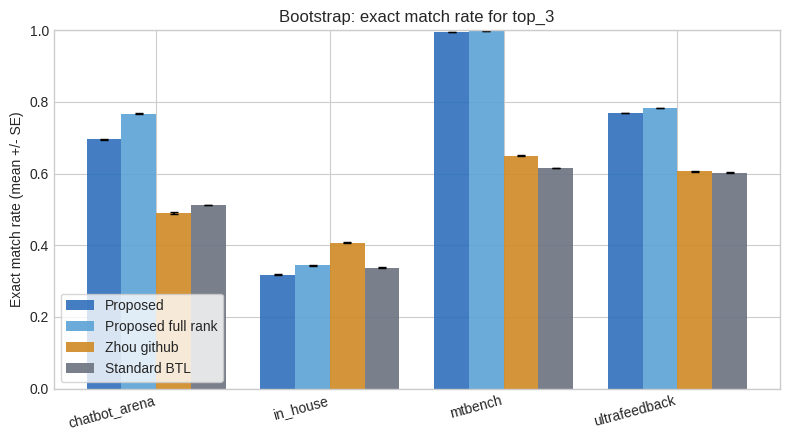

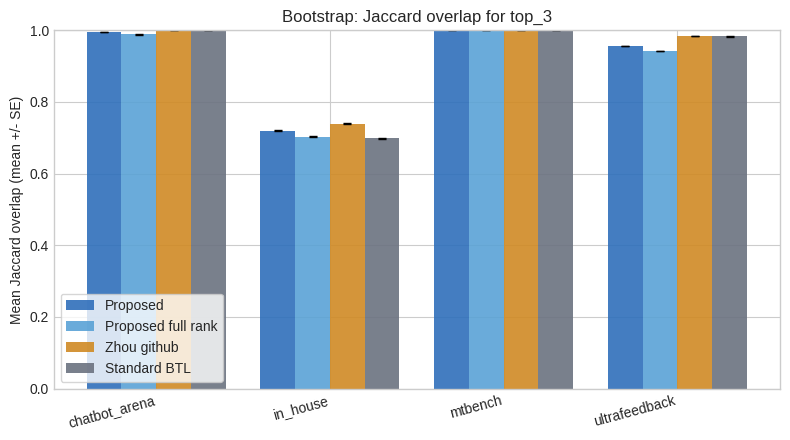

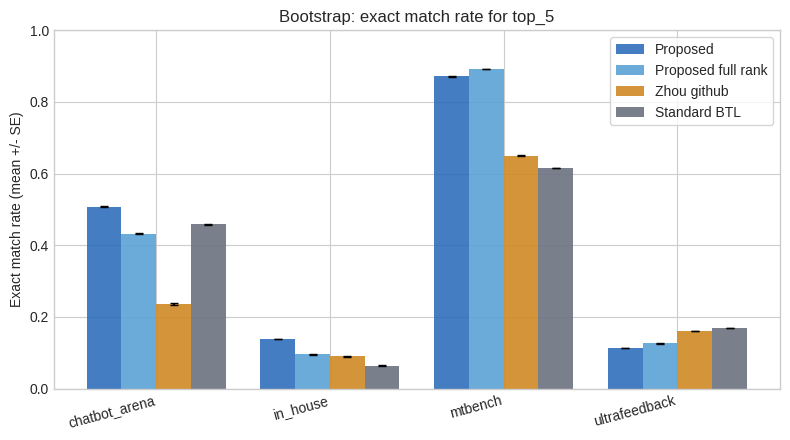

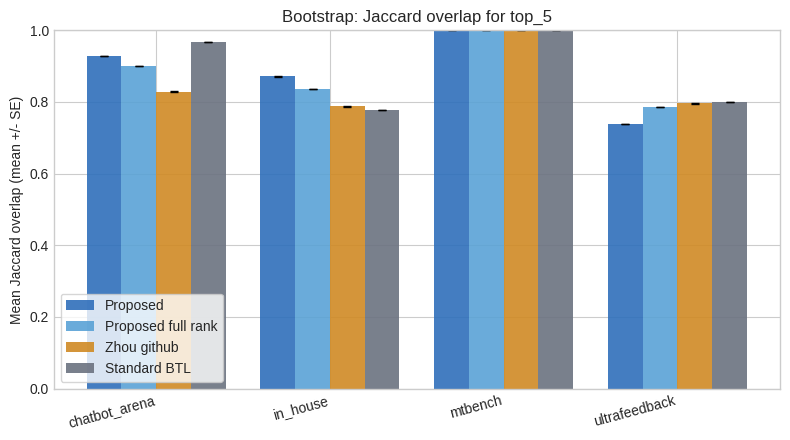

In [11]:
for top_k in sorted(bootstrap_df['top_k'].dropna().unique()):
    plot_grouped_errorbars(
        bootstrap_df[bootstrap_df['top_k'].eq(top_k)],
        metric='exact_match_rate_vs_baseline_top_k',
        title=f'Bootstrap: exact match rate for {top_k}',
        ylabel='Exact match rate (mean +/- SE)',
        save_name=f'bootstrap_{top_k}_exact_match_errorbars.png',
        methods=['proposed', 'proposed_full_rank', 'zhou_github', 'standard_btl'],
        ylim=(0, 1),
    )
    plot_grouped_errorbars(
        bootstrap_df[bootstrap_df['top_k'].eq(top_k)],
        metric='mean_jaccard_vs_baseline',
        title=f'Bootstrap: Jaccard overlap for {top_k}',
        ylabel='Mean Jaccard overlap (mean +/- SE)',
        save_name=f'bootstrap_{top_k}_jaccard_errorbars.png',
        methods=['proposed', 'proposed_full_rank', 'zhou_github', 'standard_btl'],
        ylim=(0, 1),
    )

## Selected Rank Diagnostics

In [12]:
rank_rows = []
for experiment, data in available.items():
    for dataset, dataset_summary in data.get('summary', {}).items():
        ranks = dataset_summary.get('selected_ranks') or []
        counts = pd.Series(ranks, dtype='object').value_counts(dropna=False).sort_index()
        for rank, count in counts.items():
            rank_rows.append({
                'experiment': experiment,
                'dataset': dataset,
                'selected_rank': rank,
                'count': int(count),
                'n_seeds': len(ranks),
            })
rank_df = pd.DataFrame(rank_rows)
rank_df

,experiment,dataset,selected_rank,count,n_seeds
0,stability,chatbot_arena,1,20,20
1,stability,in_house,1,20,20
2,stability,mtbench,1,19,20
3,stability,mtbench,2,1,20
4,stability,ultrafeedback,1,15,20
5,stability,ultrafeedback,2,5,20
6,near_tie_slice,chatbot_arena,1,20,20
7,near_tie_slice,in_house,1,20,20
8,near_tie_slice,mtbench,1,19,20
9,near_tie_slice,mtbench,2,1,20


## Export Tables

In [13]:
EXPORTS = {
    'stability_summary_table.csv': stability_df,
    'near_tie_slice_summary_table.csv': near_tie_df,
    'bootstrap_summary_table.csv': bootstrap_df,
    'selected_rank_counts.csv': rank_df,
}
for filename, frame in EXPORTS.items():
    out_path = SEED_SWEEP_DIR / filename
    frame.to_csv(out_path, index=False)
    print(f'Wrote {out_path}')

Wrote /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/stability_summary_table.csv
Wrote /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/near_tie_slice_summary_table.csv
Wrote /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/bootstrap_summary_table.csv
Wrote /home/jinhongd/projects/JA-Ranking/experiments/results/seed_sweeps/selected_rank_counts.csv
